# Feature Engineering - Customer Churn Prediction
Notebook này trả lời sáu câu hỏi: feature nào được giữ, feature nào được tạo, tạo như thế nào, tại sao tạo, leakage được kiểm tra ra sao, và feature nào được phép chuyển sang Preprocessing/ML.

## 01-04. Load Dataset and Dataset Overview

Đọc dữ liệu đã clean, kiểm tra kiểu dữ liệu, missing values, duplicate rows và phân phối target trước khi tạo feature.

In [121]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [122]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "customer_churn_clean.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "customer_churn_feature_engineered.csv"

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Input dataset not found: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)
TARGET = "Churned"

print(f"Dataset path: {INPUT_PATH}")
print(f"Dataset shape: {df.shape}")
display(df.head())
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}))

Dataset path: d:\Desktop\Projects\customer-churn-analytics\data\processed\customer_churn_clean.csv
Dataset shape: (50000, 25)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


,column,dtype
Age,Age,float64
Gender,Gender,str
Country,Country,str
City,City,str
Membership_Years,Membership_Years,float64
Login_Frequency,Login_Frequency,float64
Session_Duration_Avg,Session_Duration_Avg,float64
Pages_Per_Session,Pages_Per_Session,float64
Cart_Abandonment_Rate,Cart_Abandonment_Rate,float64
Wishlist_Items,Wishlist_Items,float64


In [123]:
overview = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing cells", "Duplicate rows"],
    "Value": [len(df), df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
})

target_distribution = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .reset_index(name="Count")
)
target_distribution["Percentage"] = target_distribution["Count"] / len(df) * 100

display(overview)
display(df.isna().sum().rename("Missing").to_frame())
display(target_distribution)
assert TARGET in df.columns
assert set(df[TARGET].dropna().unique()).issubset({0, 1})

,Metric,Value
0,Rows,50000
1,Columns,25
2,Missing cells,0
3,Duplicate rows,0


,Missing
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0


,Churned,Count,Percentage
0,0,35550,71.1
1,1,14450,28.9


## 05-06. Target, Feature Groups and Leakage Analysis

`Churned` chỉ được dùng làm target, không được dùng để tính bất kỳ feature nào. Các biến phụ thuộc thời gian chỉ hợp lệ khi dữ liệu là snapshot trước thời điểm dự đoán.

In [124]:
categorical_features = ["Gender", "Country", "Signup_Quarter"]
numerical_features = [
    "Age", "Membership_Years", "Login_Frequency", "Session_Duration_Avg",
    "Pages_Per_Session", "Cart_Abandonment_Rate", "Wishlist_Items", "Total_Purchases",
    "Average_Order_Value", "Days_Since_Last_Purchase", "Discount_Usage_Rate",
    "Returns_Rate", "Email_Open_Rate", "Customer_Service_Calls", "Product_Reviews_Written",
    "Social_Media_Engagement_Score", "Mobile_App_Usage", "Payment_Method_Diversity",
    "Lifetime_Value", "Credit_Balance"
]

missing_expected = sorted(set(categorical_features + numerical_features + [TARGET]) - set(df.columns))
assert not missing_expected, f"Missing expected columns: {missing_expected}"

X_original = df.drop(columns=[TARGET])
y = df[TARGET].copy()
print(f"Target: {TARGET}")
print(f"Original predictors: {X_original.shape[1]}")
print(f"Categorical: {len(categorical_features)} | Numerical: {len(numerical_features)}")
if "City" in df.columns:
    print("Note: City exists in the source data and will remain EXCLUDE_PENDING until the Country-City review is complete.")

Target: Churned
Original predictors: 24
Categorical: 3 | Numerical: 20
Note: City exists in the source data and will remain EXCLUDE_PENDING until the Country-City review is complete.


In [125]:
leakage_rows = [
    {"Feature": TARGET, "Leakage_Risk": "High", "Reason": "Target variable", "Action": "Exclude from X"},
    {"Feature": "Days_Since_Last_Purchase", "Leakage_Risk": "Medium", "Reason": "Time-dependent recency", "Action": "Keep only as pre-prediction snapshot"},
    {"Feature": "Total_Purchases", "Leakage_Risk": "Medium", "Reason": "May include future purchases", "Action": "Keep only as pre-prediction snapshot"},
    {"Feature": "Lifetime_Value", "Leakage_Risk": "Medium", "Reason": "May include future revenue", "Action": "Keep only as pre-prediction snapshot"},
    {"Feature": "Customer_Service_Calls", "Leakage_Risk": "Medium", "Reason": "May include post-prediction contacts", "Action": "Keep only as pre-prediction snapshot"},
    {"Feature": "Credit_Balance", "Leakage_Risk": "Medium", "Reason": "Time-dependent account state", "Action": "Keep only as pre-prediction snapshot"},
]

leakage_df = pd.DataFrame(leakage_rows)
display(leakage_df)

for col in X_original.columns:
    assert "churn" not in col.lower(), f"Potential target-derived feature found: {col}"
assert TARGET not in X_original.columns
print("Leakage gate passed: no target-derived predictor is present.")

,Feature,Leakage_Risk,Reason,Action
0,Churned,High,Target variable,Exclude from X
1,Days_Since_Last_Purchase,Medium,Time-dependent recency,Keep only as pre-prediction snapshot
2,Total_Purchases,Medium,May include future purchases,Keep only as pre-prediction snapshot
3,Lifetime_Value,Medium,May include future revenue,Keep only as pre-prediction snapshot
4,Customer_Service_Calls,Medium,May include post-prediction contacts,Keep only as pre-prediction snapshot
5,Credit_Balance,Medium,Time-dependent account state,Keep only as pre-prediction snapshot


Leakage gate passed: no target-derived predictor is present.


## 07-14. Feature Specification and Feature Creation

Feature gốc được giữ khi có business meaning. Feature engineered được tạo để biểu diễn tần suất, mức độ engagement, nhóm hành vi, giá trị ước tính và interaction. Không feature nào bên dưới sử dụng `Churned` để tính giá trị.

**Leakage control:** `fit_data` là internal demonstration subset để kiểm tra leakage-safe logic trong notebook này, không phải `X_train` chính thức của ML experiment. Các tham số học từ dữ liệu (`min`, `max`, quantiles và ngưỡng grouping) chỉ được fit trên subset này trong phần minh họa. Pipeline production phải refit toàn bộ tham số trên `X_train` chính thức, rồi chỉ transform validation/test.

**Range behavior:** `Engagement_Score` không bị clip. Nếu dữ liệu mới nằm ngoài train range, giá trị normalized có thể nhỏ hơn 0 hoặc lớn hơn 1; đây là hành vi được ghi nhận để bước preprocessing/ML quyết định.

In [126]:
df_fe = df.copy()

# Fit transformation parameters on a deterministic training subset only.
# The split is created before feature construction and does not use Churned.
RANDOM_STATE = 42
TRAIN_FRACTION = 0.80
rng = np.random.default_rng(RANDOM_STATE)
shuffled_positions = rng.permutation(len(df_fe))
train_size = int(len(df_fe) * TRAIN_FRACTION)
train_positions = shuffled_positions[:train_size]
train_mask = np.zeros(len(df_fe), dtype=bool)
train_mask[train_positions] = True

fit_data = df_fe.loc[train_mask].copy()
transform_data = df_fe.copy()
print(f"Transformation fit rows: {fit_data.shape[0]}")
print(f"Transformation application rows: {transform_data.shape[0]}")
print("No target values were used to create the split or fit feature transformations.")

Transformation fit rows: 40000
Transformation application rows: 50000
No target values were used to create the split or fit feature transformations.


In [127]:
# Engagement_Score formula: mean of train-fitted min-max normalized inputs.
# The following fitted parameters must be reproduced inside the ML pipeline.
engagement_inputs = [
    "Login_Frequency", "Session_Duration_Avg", "Pages_Per_Session",
    "Email_Open_Rate", "Mobile_App_Usage", "Social_Media_Engagement_Score"
]
engagement_min = fit_data[engagement_inputs].min()
engagement_max = fit_data[engagement_inputs].max()
engagement_range = (engagement_max - engagement_min).replace(0, 1.0)
engagement_normalized = (transform_data[engagement_inputs] - engagement_min) / engagement_range
df_fe["Engagement_Score"] = engagement_normalized.mean(axis=1)

In [128]:
# Purchase frequency is a rate-like proxy. Its validity depends on the source definition of Total_Purchases.
zero_membership_years = int((df_fe["Membership_Years"] == 0).sum())
denominator = df_fe["Membership_Years"].replace(0, np.nan)
df_fe["Purchase_Frequency"] = (df_fe["Total_Purchases"] / denominator).replace([np.inf, -np.inf], np.nan)
#Purchase Frequency=Membership Years/Total Purchases​

In [129]:
# Group thresholds are fitted from train data only and then applied to every row.
recency_quantiles = fit_data["Days_Since_Last_Purchase"].quantile([0.25, 0.50, 0.75]).to_dict()
frequency_quantiles = df_fe.loc[train_mask, "Purchase_Frequency"].quantile([0.33, 0.67]).to_dict()
service_quantiles = fit_data["Customer_Service_Calls"].quantile([0.25, 0.50, 0.75]).to_dict()
cart_quantiles = fit_data["Cart_Abandonment_Rate"].quantile([0.33, 0.67]).to_dict()

thresholds = pd.DataFrame({
    "Feature": ["Days_Since_Last_Purchase", "Purchase_Frequency", "Customer_Service_Calls", "Cart_Abandonment_Rate"],
    "Thresholds_Fit_On_Train": [recency_quantiles, frequency_quantiles, service_quantiles, cart_quantiles],
    "Rule": ["25/50/75% quantiles", "33/67% quantiles", "25/50/75% quantiles", "33/67% quantiles"],
})
display(thresholds)

def validate_unique_bins(values, feature_name):
    edges = list(values)
    if len(set(edges)) != len(edges):
        raise ValueError(
            f"{feature_name}: quantile thresholds are not unique: {values}"
        )

validate_unique_bins(
    [
        recency_quantiles[0.25],
        recency_quantiles[0.50],
        recency_quantiles[0.75]
    ],
    "Days_Since_Last_Purchase"
)


validate_unique_bins(
    [
        frequency_quantiles[0.33],
        frequency_quantiles[0.67]
    ],
    "Purchase_Frequency"
)

validate_unique_bins(
    [
        service_quantiles[0.25],
        service_quantiles[0.50],
        service_quantiles[0.75]
    ],
    "Customer_Service_Calls"
)

validate_unique_bins(
    [
        cart_quantiles[0.33],
        cart_quantiles[0.67]
    ],
    "Cart_Abandonment_Rate"
)

,Feature,Thresholds_Fit_On_Train,Rule
0,Days_Since_Last_Purchase,"{0.25: 9.0, 0.5: 21.0, 0.75: 40.0}",25/50/75% quantiles
1,Purchase_Frequency,"{0.33: 3.1818181818181817, 0.67: 7.14285714285...",33/67% quantiles
2,Customer_Service_Calls,"{0.25: 4.0, 0.5: 5.0, 0.75: 7.0}",25/50/75% quantiles
3,Cart_Abandonment_Rate,"{0.33: 50.5, 0.67: 65.0}",33/67% quantiles


In [130]:
# Purchase_Frequency_Group is created only after Purchase_Frequency and its train quantiles exist.
df_fe["Purchase_Recency_Group"] = pd.cut(
    df_fe["Days_Since_Last_Purchase"],
    bins=[-np.inf, recency_quantiles[0.25], recency_quantiles[0.50], recency_quantiles[0.75], np.inf],
    labels=["Recent", "Moderate", "Inactive", "Very_Inactive"],
    include_lowest=True,
)
df_fe["Purchase_Frequency_Group"] = pd.cut(
    df_fe["Purchase_Frequency"],
    bins=[-np.inf, frequency_quantiles[0.33], frequency_quantiles[0.67], np.inf],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)
df_fe["Service_Call_Group"] = pd.cut(
    df_fe["Customer_Service_Calls"],
    bins=[-np.inf, service_quantiles[0.25], service_quantiles[0.50], service_quantiles[0.75], np.inf],
    labels=["No_or_Few_Calls", "Moderate", "Frequent", "Very_Frequent"],
    include_lowest=True,
)
df_fe["Cart_Abandonment_Group"] = pd.cut(
    df_fe["Cart_Abandonment_Rate"],
    bins=[-np.inf, cart_quantiles[0.33], cart_quantiles[0.67], np.inf],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

In [131]:
# Estimated value is valid only if Total_Purchases is an order count and Average_Order_Value is monetary value per order.
df_fe["Estimated_Purchase_Value"] = df_fe["Total_Purchases"] * df_fe["Average_Order_Value"]
df_fe["Cart_Recency_Interaction"] = df_fe["Cart_Abandonment_Rate"] * df_fe["Days_Since_Last_Purchase"]
low_engagement_threshold = float(pd.Series(df_fe.loc[train_mask, "Engagement_Score"]).quantile(0.25))
long_recency_threshold = recency_quantiles[0.75]
df_fe["Low_Engagement_Recency"] = (
    (df_fe["Engagement_Score"] <= low_engagement_threshold)
    & (df_fe["Days_Since_Last_Purchase"] >= long_recency_threshold)
).astype(int)

engineered_features = [
    "Engagement_Score", "Purchase_Frequency", "Purchase_Recency_Group", "Purchase_Frequency_Group",
    "Service_Call_Group", "Cart_Abandonment_Group", "Estimated_Purchase_Value",
    "Cart_Recency_Interaction", "Low_Engagement_Recency"
]
print(f"Created {len(engineered_features)} engineered features.")
print(f"Membership_Years equal to zero: {zero_membership_years}")
display(df_fe[engineered_features].head())

Created 9 engineered features.
Membership_Years equal to zero: 0


,Engagement_Score,Purchase_Frequency,Purchase_Recency_Group,Purchase_Frequency_Group,Service_Call_Group,Cart_Abandonment_Group,Estimated_Purchase_Value,Cart_Recency_Interaction,Low_Engagement_Recency
0,0.265693,3.103448,Inactive,Low,Very_Frequent,Medium,852.48,1720.4,0
1,0.411031,12.500000,Very_Inactive,High,Frequent,Low,1649.00,2676.7,0
2,0.163465,3.103448,Moderate,Low,No_or_Few_Calls,High,1489.68,779.9,0
3,0.531109,5.769231,Very_Inactive,Medium,No_or_Few_Calls,Low,2209.95,1959.9,0
4,0.622693,10.322581,Very_Inactive,High,No_or_Few_Calls,Low,4521.60,1394.3,0


In [132]:
purchase_definition_check = pd.DataFrame({
    "Field": ["Total_Purchases", "Average_Order_Value"],
    "Observed_Min": [df["Total_Purchases"].min(), df["Average_Order_Value"].min()],
    "Observed_Max": [df["Total_Purchases"].max(), df["Average_Order_Value"].max()],
    "Has_Decimal_Values": [
        bool((df["Total_Purchases"] % 1 != 0).any()),
        bool((df["Average_Order_Value"] % 1 != 0).any()),
    ],
    "Interpretation_Required": [
        "Confirm whether this is order count or purchase volume before treating Purchase_Frequency as purchases/year.",
        "Confirm whether this is monetary value per order before using Estimated_Purchase_Value.",
    ],
})
display(purchase_definition_check)
print("Purchase-derived features remain TEST until the source data dictionary confirms these definitions.")

,Field,Observed_Min,Observed_Max,Has_Decimal_Values,Interpretation_Required
0,Total_Purchases,0.00,129.000000,False,Confirm whether this is order count or purchas...
1,Average_Order_Value,26.38,9666.379178,True,Confirm whether this is monetary value per ord...


Purchase-derived features remain TEST until the source data dictionary confirms these definitions.


In [ ]:
#hồ sơ lí lịch của toàn bộ features(feature_dictionary)
business_meanings = {
    "Age": "Customer age at the observation snapshot.",
    "Membership_Years": "Customer tenure in years.",
    "Login_Frequency": "How frequently the customer logs into the platform.",
    "Session_Duration_Avg": "Average duration of a customer session.",
    "Pages_Per_Session": "Average number of pages viewed per session.",
    "Cart_Abandonment_Rate": "Share of shopping-cart activity abandoned before purchase.",
    "Wishlist_Items": "Number of products currently saved to the wishlist.",
    "Total_Purchases": "Observed purchase-related volume; exact count versus volume requires source confirmation.",
    "Average_Order_Value": "Average monetary value per order, subject to source-definition confirmation.",
    "Days_Since_Last_Purchase": "Days since the customer's most recent purchase.",
    "Discount_Usage_Rate": "Share of purchases or activity associated with discount usage.",
    "Returns_Rate": "Share of purchase activity associated with returned items.",
    "Email_Open_Rate": "Rate at which the customer opens email communications.",
    "Customer_Service_Calls": "Number of customer-service contacts, representing support needs or service friction.",
    "Product_Reviews_Written": "Number of product reviews written by the customer.",
    "Social_Media_Engagement_Score": "Customer engagement with social-media activity.",
    "Mobile_App_Usage": "Customer activity level in the mobile application.",
    "Payment_Method_Diversity": "Number of distinct payment methods used by the customer.",
    "Lifetime_Value": "Observed customer value accumulated up to the snapshot.",
    "Credit_Balance": "Customer credit or account balance at the snapshot.",
}

feature_categories = {
    "Age": "Demographic",
    "Gender": "Demographic",
    "Country": "Demographic",
    "City": "Demographic",
    "Signup_Quarter": "Customer Lifecycle",
    "Membership_Years": "Customer Lifecycle",
    "Login_Frequency": "Engagement",
    "Session_Duration_Avg": "Engagement",
    "Pages_Per_Session": "Engagement",
    "Wishlist_Items": "Engagement",
    "Email_Open_Rate": "Engagement",
    "Mobile_App_Usage": "Engagement",
    "Social_Media_Engagement_Score": "Engagement",
    "Product_Reviews_Written": "Engagement",
    "Cart_Abandonment_Rate": "Cart",
    "Total_Purchases": "Purchase",
    "Average_Order_Value": "Purchase",
    "Days_Since_Last_Purchase": "Purchase",
    "Discount_Usage_Rate": "Purchase",
    "Returns_Rate": "Purchase",
    "Payment_Method_Diversity": "Purchase",
    "Customer_Service_Calls": "Customer Service",
    "Lifetime_Value": "Customer Value",
    "Credit_Balance": "Customer Value",
}

In [134]:
feature_metadata = []

for feature in categorical_features:
    feature_metadata.append({
        "Feature": feature,
        "Category": feature_categories.get(feature, "Other"),
        "Source": "Clean dataset",
        "Data_Used": feature,
        "Original_Engineered": "Original",
        "Formula": "Original value",
        "Reason": "Retain customer context for ML comparison",
        "Leakage_Risk": "Low",
        "Data_Type": "Categorical",
        "Validation": "Category counts, rare-category frequency and missing check",
        "ML_Decision": "TEST",
        "Business_Meaning": "Quarter in which the customer signed up, representing lifecycle timing." if feature == "Signup_Quarter" else f"Customer {feature.lower()}"
    })

for feature in numerical_features:
    feature_metadata.append({
        "Feature": feature,
        "Category": feature_categories.get(feature, "Other"),
        "Source": "Clean dataset",
        "Data_Used": feature,
        "Original_Engineered": "Original",
        "Formula": "Original value",
        "Reason": "Business-meaningful predictor retained for baseline ML",
        "Leakage_Risk": "Medium - pre-prediction snapshot required" if feature in ["Days_Since_Last_Purchase", "Total_Purchases", "Lifetime_Value", "Customer_Service_Calls", "Credit_Balance"] else "Low",
        "Data_Type": "Numeric",
        "Validation": "Range, distribution, missing and train/test availability review",
        "ML_Decision": "TEST" if feature == "Payment_Method_Diversity" else "KEEP",
        "Business_Meaning": business_meanings.get(feature, f"Customer {feature.replace('_', ' ').lower()}")
    })


In [135]:
if "City" in df_fe.columns:
    city_country_table = pd.crosstab(df_fe["Country"], df_fe["City"])
    city_country_summary = city_country_table.gt(0).sum(axis=0)
    city_multi_country = city_country_summary[city_country_summary > 1].index.tolist()
    city_cardinality = int(df_fe["City"].nunique())
    if city_multi_country:
        city_decision = "EXCLUDE_PENDING"
        city_reason = "Data-quality review required because a city maps to multiple countries."
    else:
        city_decision = "EXCLUDE"
        city_reason = (
            "City is excluded from the current baseline to keep the feature matrix compact; "
            "its incremental predictive value can be evaluated in a later ML experiment."
        )
    feature_metadata.append({
        "Feature": "City",
        "Category": feature_categories["City"],
        "Source": "Clean dataset",
        "Data_Used": "City, Country",
        "Original_Engineered": "Original",
        "Formula": "Original value",
        "Reason": city_reason,
        "Leakage_Risk": "Low",
        "Data_Type": "Categorical",
        "Validation": "Crosstab Country by City, mapping uniqueness and category cardinality",
        "ML_Decision": city_decision,
        "Business_Meaning": "Customer city of residence or activity"
    })
    display(city_country_table)
    print(f"Cities associated with multiple countries: {city_multi_country}")
    print(f"City decision: {city_decision} ({city_cardinality} categories)")

City,Adelaide,Bangalore,Berlin,Birmingham,Brisbane,Calgary,Chennai,Chicago,Cologne,Delhi,...,Ottawa,Paris,Perth,Phoenix,Sydney,Tokyo,Toronto,Toulouse,Vancouver,Yokohama
Country,,,,,,,,,,,,,,,,,,,,,
Australia,817,0,0,0,794,0,0,0,0,0,...,0,0,817,0,828,0,0,0,0,0
Canada,0,0,0,0,0,1204,0,0,0,0,...,1182,0,0,0,0,0,1209,0,1181,0
France,0,0,0,0,0,0,0,0,0,0,...,0,776,0,0,0,0,0,815,0,0
Germany,0,0,1013,0,0,0,0,0,1033,0,...,0,0,0,0,0,0,0,0,0,0
India,0,698,0,0,0,0,736,0,0,693,...,0,0,0,0,0,0,0,0,0,0
Japan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,537,0,0,0,494
UK,0,0,0,1535,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
USA,0,0,0,0,0,0,0,3475,0,0,...,0,0,0,3490,0,0,0,0,0,0


Cities associated with multiple countries: []
City decision: EXCLUDE (40 categories)


In [136]:
engineered_metadata = [
    ("Engagement_Score", "Engagement", ", ".join(engagement_inputs), "mean(train-fitted min-max normalized engagement inputs)", "Summarize engagement on a common scale", "Low", "Numeric", "TEST", "Composite engagement intensity across platform, email, app and social activity."),
    ("Purchase_Frequency", "Purchase", "Total_Purchases, Membership_Years", "Total_Purchases / Membership_Years", "Represent a rate-like purchase activity proxy", "Medium - pre-prediction snapshot required", "Numeric", "TEST", "Purchase-related activity per membership year; semantics depend on Total_Purchases definition."),
    ("Purchase_Recency_Group", "Purchase", "Days_Since_Last_Purchase", "Bins from train-fitted recency quartiles", "Compare recency bands with a categorical representation", "Medium - snapshot and train-fit bins required", "Categorical", "TEST", "Segment based on how recently the customer purchased."),
    ("Purchase_Frequency_Group", "Purchase", "Purchase_Frequency", "Bins from train-fitted frequency quantiles", "Compare purchase-rate bands with a categorical representation", "Medium - snapshot and train-fit bins required", "Categorical", "TEST", "Segment based on purchase-related activity rate."),
    ("Service_Call_Group", "Customer Service", "Customer_Service_Calls", "Bins from train-fitted service-call quartiles", "Compare numeric and categorical service-contact representations", "Medium - snapshot and train-fit bins required", "Categorical", "TEST", "Segment based on customer-service contact frequency."),
    ("Cart_Abandonment_Group", "Cart", "Cart_Abandonment_Rate", "Bins from train-fitted abandonment tertiles", "Test nonlinear cart-abandonment effects", "Low", "Categorical", "TEST", "Segment based on cart abandonment behavior."),
    ("Estimated_Purchase_Value", "Customer Value", "Total_Purchases, Average_Order_Value", "Total_Purchases * Average_Order_Value", "Approximate value only if purchases are order count and order value is monetary", "Medium - pre-prediction snapshot required", "Numeric", "TEST", "Estimated cumulative purchase value under the confirmed source definitions."),
    ("Cart_Recency_Interaction", "Interaction", "Cart_Abandonment_Rate, Days_Since_Last_Purchase", "Cart_Abandonment_Rate * Days_Since_Last_Purchase", "Capture joint high-abandonment and stale-purchase behavior", "Medium - pre-prediction snapshot required", "Numeric", "TEST", "Combined signal of cart abandonment and purchase recency."),
    ("Low_Engagement_Recency", "Interaction", "Engagement_Score, Days_Since_Last_Purchase", "Engagement <= train Q1 AND recency >= train Q3", "Flag customers with jointly weak engagement and long recency", "Medium - train-fit thresholds required", "Binary", "TEST", "Flag for low engagement combined with long purchase recency."),
]
for feature, category, data_used, formula, reason, risk, data_type, decision, meaning in engineered_metadata:
    feature_metadata.append({
        "Feature": feature,
        "Category": category,
        "Source": "Derived from pre-prediction customer attributes",
        "Data_Used": data_used,
        "Original_Engineered": "Engineered",
        "Formula": formula,
        "Reason": reason,
        "Leakage_Risk": risk,
        "Data_Type": data_type,
        "Validation": "Missing, infinite, range, distribution, positive-rate and redundancy checks",
        "ML_Decision": decision,
        "Business_Meaning": meaning
    })

feature_dictionary = pd.DataFrame(feature_metadata)
display(feature_dictionary[["Feature", "Category", "Data_Used", "Original_Engineered", "Formula", "Leakage_Risk", "ML_Decision"]])

,Feature,Category,Data_Used,Original_Engineered,Formula,Leakage_Risk,ML_Decision
0,Gender,Demographic,Gender,Original,Original value,Low,TEST
1,Country,Demographic,Country,Original,Original value,Low,TEST
2,Signup_Quarter,Customer Lifecycle,Signup_Quarter,Original,Original value,Low,TEST
3,Age,Demographic,Age,Original,Original value,Low,KEEP
4,Membership_Years,Customer Lifecycle,Membership_Years,Original,Original value,Low,KEEP
5,Login_Frequency,Engagement,Login_Frequency,Original,Original value,Low,KEEP
6,Session_Duration_Avg,Engagement,Session_Duration_Avg,Original,Original value,Low,KEEP
7,Pages_Per_Session,Engagement,Pages_Per_Session,Original,Original value,Low,KEEP
8,Cart_Abandonment_Rate,Cart,Cart_Abandonment_Rate,Original,Original value,Low,KEEP
9,Wishlist_Items,Engagement,Wishlist_Items,Original,Original value,Low,KEEP


## 15-16. Feature Validation and Redundancy Check

Validation không chọn feature dựa trên correlation đơn lẻ. Nó kiểm tra missing, infinite, duplicate, constant/near-zero variance, phân phối và các cặp numerical có tương quan cao để ghi nhận cho bước ML.

In [137]:
numeric_fe = df_fe.select_dtypes(include=np.number)
categorical_fe = df_fe.select_dtypes(exclude=np.number)

duplicate_rows = int(df_fe.duplicated().sum())
validation_summary = pd.DataFrame({
    "Check": ["Missing values", "Infinite numeric values", "Duplicate columns", "Duplicate rows", "Constant numeric features"],
    "Count": [
        int(df_fe.isna().sum().sum()),
        int(np.isinf(numeric_fe.to_numpy()).sum()),
        int(df_fe.columns.duplicated().sum()),
        duplicate_rows,
        int((numeric_fe.nunique(dropna=False) <= 1).sum()),
    ],
})

display(validation_summary)

assert validation_summary.loc[validation_summary["Check"] == "Missing values", "Count"].item() == 0, "Dữ liệu chứa giá trị Missing"
assert validation_summary.loc[validation_summary["Check"] == "Infinite numeric values", "Count"].item() == 0, "Dữ liệu chứa giá trị Vô cực (Inf)"
assert validation_summary.loc[validation_summary["Check"] == "Duplicate columns", "Count"].item() == 0, "Có cột bị trùng tên"
assert validation_summary.loc[validation_summary["Check"] == "Duplicate rows", "Count"].item() == 0, "Có dòng dữ liệu trùng lặp"
assert validation_summary.loc[validation_summary["Check"] == "Constant numeric features", "Count"].item() == 0, "Có biến số học chỉ chứa 1 giá trị duy nhất"

,Check,Count
0,Missing values,0
1,Infinite numeric values,0
2,Duplicate columns,0
3,Duplicate rows,0
4,Constant numeric features,0


In [138]:
numeric_unique_ratio = numeric_fe.nunique(dropna=False).div(len(numeric_fe)).sort_values().rename("Unique_Ratio").to_frame()
numeric_near_zero_variance = numeric_unique_ratio[numeric_unique_ratio["Unique_Ratio"] <= 0.01]

categorical_frequency = []
for feature in categorical_fe.columns:
    frequencies = categorical_fe[feature].value_counts(normalize=True, dropna=False)
    categorical_frequency.append({
        "Feature": feature,
        "Categories": int(categorical_fe[feature].nunique(dropna=False)),
        "Smallest_Category_Percentage": float(frequencies.min() * 100),
        "Largest_Category_Percentage": float(frequencies.max() * 100),
    })
categorical_frequency = pd.DataFrame(categorical_frequency).sort_values("Smallest_Category_Percentage")

display(numeric_near_zero_variance)
display(categorical_frequency)

,Unique_Ratio
Low_Engagement_Recency,0.00004
Churned,0.00004
Payment_Method_Diversity,0.00010
Product_Reviews_Written,0.00036
Customer_Service_Calls,0.00042
Wishlist_Items,0.00050
Login_Frequency,0.00092
Age,0.00116
Total_Purchases,0.00192
Membership_Years,0.00400


,Feature,Categories,Smallest_Category_Percentage,Largest_Category_Percentage
2,City,40,0.988,7.098
0,Gender,3,1.874,50.232
1,Country,8,5.096,34.768
6,Service_Call_Group,4,14.924,35.516
4,Purchase_Recency_Group,4,21.612,29.142
3,Signup_Quarter,4,24.906,25.116
5,Purchase_Frequency_Group,3,32.918,33.916
7,Cart_Abandonment_Group,3,33.048,33.864


In [148]:
range_specs = {
    "Age": (15, 100),
    "Membership_Years": (0, np.inf),
    "Login_Frequency": (0, np.inf),
    "Session_Duration_Avg": (0, np.inf),
    "Pages_Per_Session": (0, np.inf),
    "Cart_Abandonment_Rate": (0, 100),
    "Wishlist_Items": (0, np.inf),
    "Total_Purchases": (0, np.inf),
    "Average_Order_Value": (0, np.inf),
    "Discount_Usage_Rate": (0, 100),
    "Returns_Rate": (0, 100),
    "Email_Open_Rate": (0, 100),
    "Days_Since_Last_Purchase": (0, np.inf),
    "Customer_Service_Calls": (0, np.inf),
    "Product_Reviews_Written": (0, np.inf),
    "Social_Media_Engagement_Score": (0, 100),
    "Mobile_App_Usage": (0, np.inf),
    "Payment_Method_Diversity": (0, np.inf),
    "Lifetime_Value": (0, np.inf),
}

range_validation = []
for feature, (expected_min, expected_max) in range_specs.items():
    actual_min = float(df_fe[feature].min())
    actual_max = float(df_fe[feature].max())
    invalid_count = int(((df_fe[feature] < expected_min) | (df_fe[feature] > expected_max)).sum())
    range_validation.append({
        "Feature": feature,
        "Expected_Min": expected_min,
        "Expected_Max": expected_max,
        "Actual_Min": actual_min,
        "Actual_Max": actual_max,
        "Invalid_Count": invalid_count,
        "Status": "PASS" if invalid_count == 0 else "REVIEW",
    })
    
range_validation = pd.DataFrame(range_validation)
display(range_validation)

assert (range_validation["Status"] == "PASS").all(), "Có dữ liệu vi phạm dải giá trị nghiệp vụ (Business Range)"

,Feature,Expected_Min,Expected_Max,Actual_Min,Actual_Max,Invalid_Count,Status
0,Age,15,100.0,18.00,75.000000,0,PASS
1,Membership_Years,0,inf,0.10,10.000000,0,PASS
2,Login_Frequency,0,inf,0.00,46.000000,0,PASS
3,Session_Duration_Avg,0,inf,1.00,75.600000,0,PASS
4,Pages_Per_Session,0,inf,1.00,24.100000,0,PASS
5,Cart_Abandonment_Rate,0,100.0,0.00,100.000000,0,PASS
6,Wishlist_Items,0,inf,0.00,28.000000,0,PASS
7,Total_Purchases,0,inf,0.00,129.000000,0,PASS
8,Average_Order_Value,0,inf,26.38,9666.379178,0,PASS
9,Discount_Usage_Rate,0,100.0,0.24,99.960000,0,PASS


In [140]:
engagement_out_of_train_range = pd.DataFrame({
    "Feature": engagement_inputs,
    "Train_Min": engagement_min.values,
    "Train_Max": engagement_max.values,
    "Below_Train_Min": [int((transform_data[feature] < engagement_min[feature]).sum()) for feature in engagement_inputs],
    "Above_Train_Max": [int((transform_data[feature] > engagement_max[feature]).sum()) for feature in engagement_inputs],
})
display(engagement_out_of_train_range)
print("Engagement_Score is not clipped; out-of-train-range values are retained for downstream preprocessing decisions.")

# Recreate derived features if this validation cell is run independently.
if "Engagement_Score" not in df_fe.columns:
    engagement_normalized = (transform_data[engagement_inputs] - engagement_min) / engagement_range
    df_fe["Engagement_Score"] = engagement_normalized.mean(axis=1)
if "Low_Engagement_Recency" not in df_fe.columns:
    df_fe["Low_Engagement_Recency"] = (
        (df_fe["Engagement_Score"] <= low_engagement_threshold)
        & (df_fe["Days_Since_Last_Purchase"] >= long_recency_threshold)
    ).astype(int)

low_engagement_recency_rate = pd.DataFrame({
    "Feature": ["Low_Engagement_Recency"],
    "Positive_Count": [int(df_fe["Low_Engagement_Recency"].sum())],
    "Negative_Count": [int((df_fe["Low_Engagement_Recency"] == 0).sum())],
    "Positive_Rate": [float(df_fe["Low_Engagement_Recency"].mean())],
})
display(low_engagement_recency_rate)

,Feature,Train_Min,Train_Max,Below_Train_Min,Above_Train_Max
0,Login_Frequency,0.0,46.0,0,0
1,Session_Duration_Avg,1.0,75.6,0,0
2,Pages_Per_Session,1.0,23.9,0,1
3,Email_Open_Rate,0.0,81.9,0,2
4,Mobile_App_Usage,0.0,61.9,0,0
5,Social_Media_Engagement_Score,0.0,100.0,0,0


Engagement_Score is not clipped; out-of-train-range values are retained for downstream preprocessing decisions.


,Feature,Positive_Count,Negative_Count,Positive_Rate
0,Low_Engagement_Recency,3046,46954,0.06092


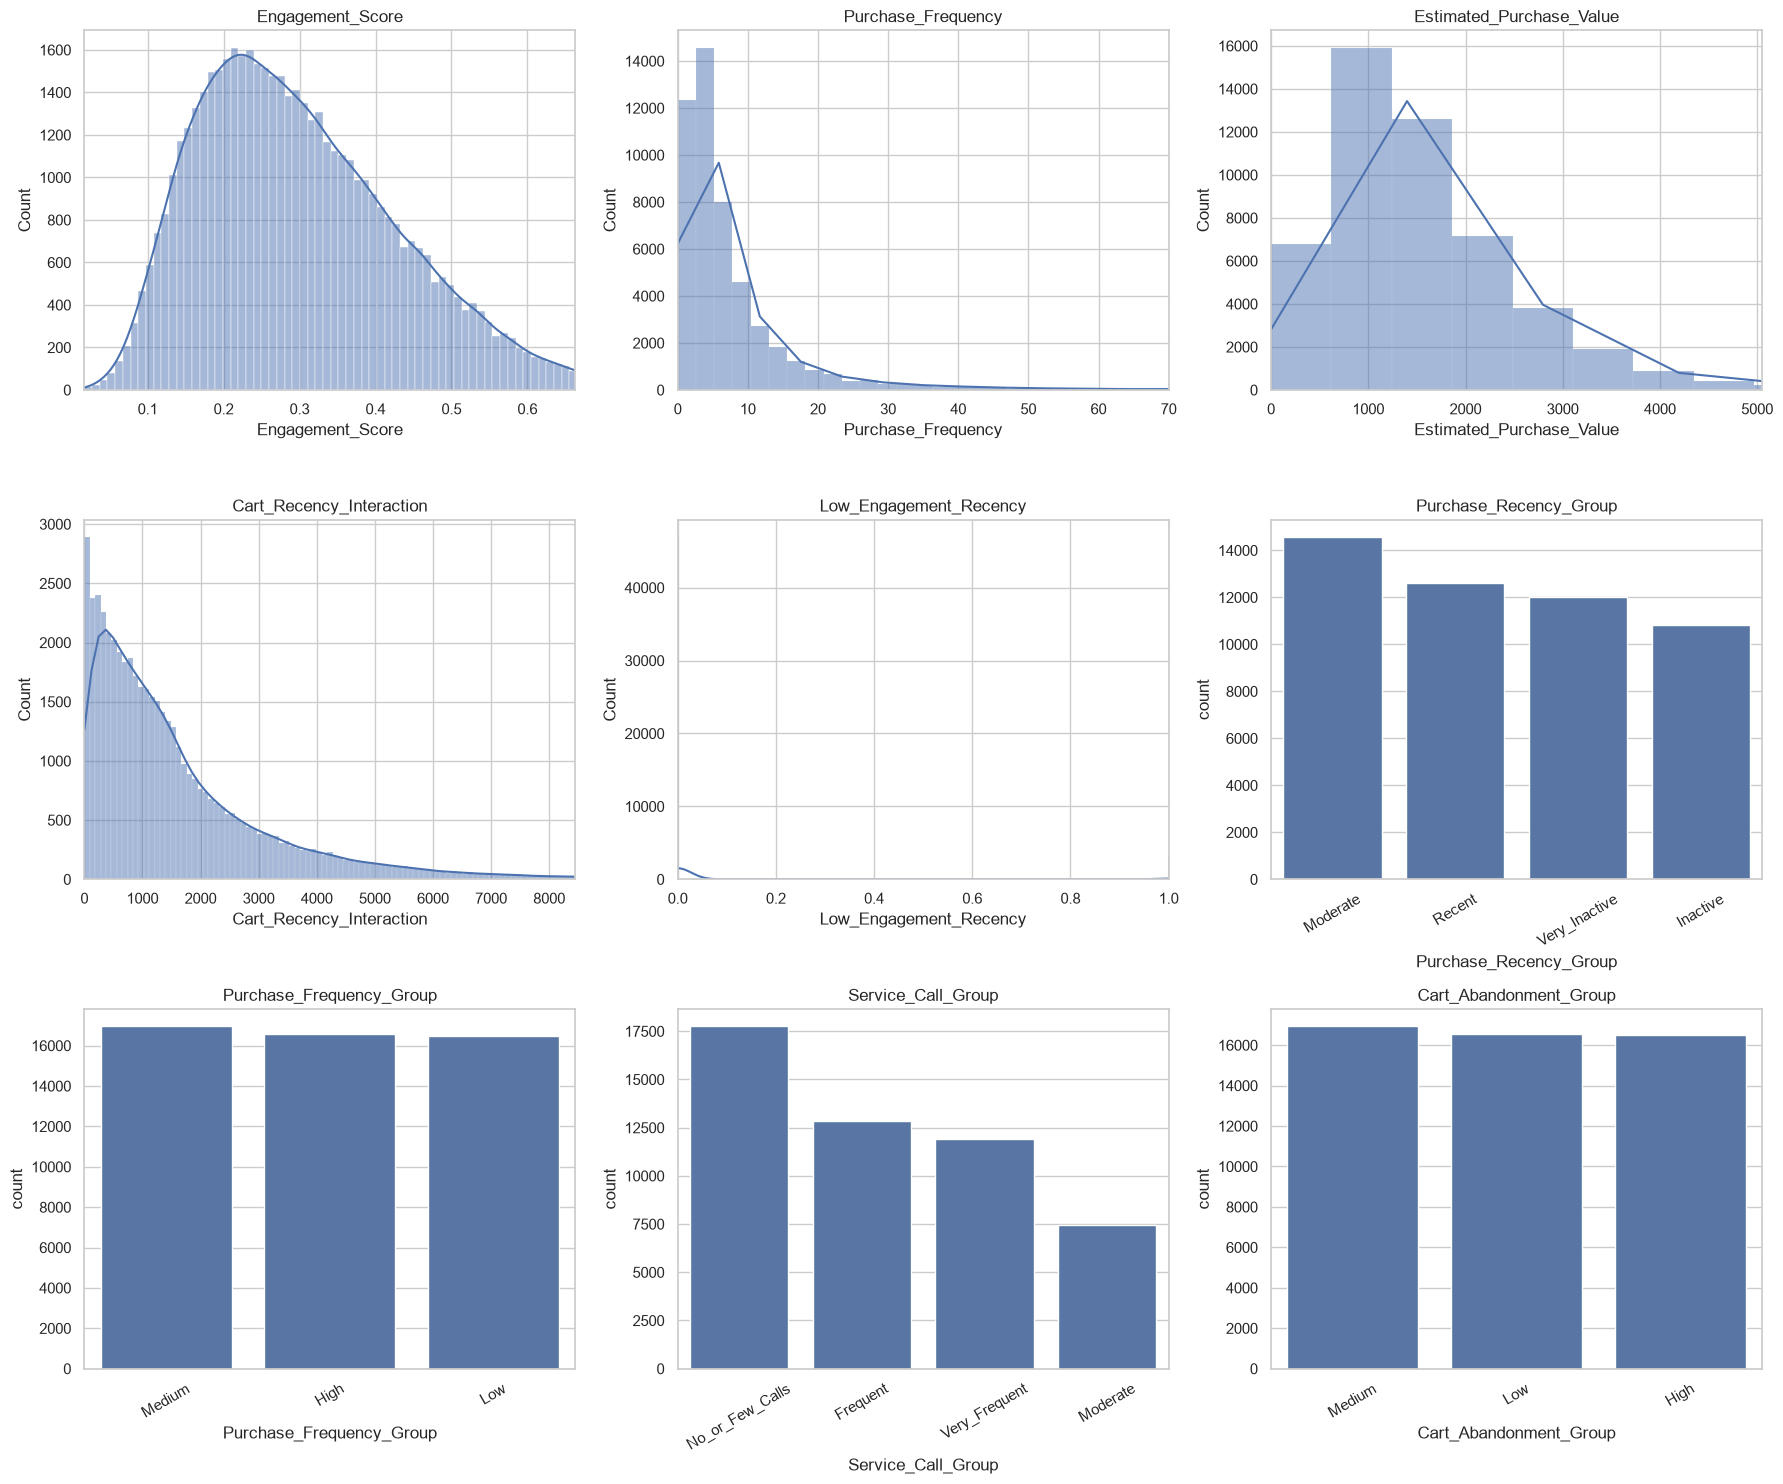

Feature validation passed: plotted all 9 engineered features.


In [151]:
engineered_numeric = [
    feature for feature in engineered_features
    if feature in df_fe.columns and pd.api.types.is_numeric_dtype(df_fe[feature])
]
engineered_categorical = [
    feature for feature in engineered_features
    if feature in df_fe.columns and not pd.api.types.is_numeric_dtype(df_fe[feature])
]

plot_features = [(feature, "numeric") for feature in engineered_numeric]
plot_features += [(feature, "categorical") for feature in engineered_categorical]
plot_columns = 3
plot_rows = int(np.ceil(len(plot_features) / plot_columns))
fig, axes = plt.subplots(
    plot_rows,
    plot_columns,
    figsize=(18, 5 * plot_rows),
    squeeze=False,
)

for axis, (feature, feature_type) in zip(axes.ravel(), plot_features):
    if feature_type == "numeric":
        values = df_fe[feature].replace([np.inf, -np.inf], np.nan).dropna()
        sns.histplot(values, kde=True, ax=axis)

        upper_limit = values.quantile(0.99)
        lower_limit = values.min()
        
        if lower_limit < upper_limit:
            axis.set_xlim(left=lower_limit, right=upper_limit)

    else:
        sns.countplot(data=df_fe, x=feature, order=df_fe[feature].value_counts().index, ax=axis)
        axis.tick_params(axis="x", rotation=30)
    axis.set_title(feature)

for axis in axes.ravel()[len(plot_features):]:
    axis.remove()

plt.tight_layout()
plt.show()


assert set(engineered_features).issubset(df_fe.columns)
print(f"Feature validation passed: plotted all {len(engineered_features)} engineered features.")

## Descriptive Validation of Engineered Groups

Các bảng dưới đây chỉ mô tả phân phối và churn rate theo nhóm để kiểm tra business signal. Chúng không dùng target để tạo feature và không quyết định feature nào được giữ; predictive usefulness sẽ được đánh giá ở bước ML.

In [142]:
descriptive_group_features = [
    "Purchase_Recency_Group",
    "Purchase_Frequency_Group",
    "Service_Call_Group",
    "Cart_Abandonment_Group",
]
descriptive_validation = []
for feature in descriptive_group_features:
    group_summary = (
        df_fe.groupby(feature, observed=False)[TARGET]
        .agg(Customer_Count="size", Churn_Rate="mean")
        .reset_index()
    )
    group_summary.insert(0, "Feature", feature)
    descriptive_validation.append(group_summary)
descriptive_validation = pd.concat(descriptive_validation, ignore_index=True)
display(descriptive_validation)
print("Descriptive churn-rate tables are for interpretation only; ML performance remains the selection criterion.")

,Feature,Purchase_Recency_Group,Customer_Count,Churn_Rate,Purchase_Frequency_Group,Service_Call_Group,Cart_Abandonment_Group
0,Purchase_Recency_Group,Recent,12594,0.224234,NaN,NaN,NaN
1,Purchase_Recency_Group,Moderate,14571,0.267175,NaN,NaN,NaN
2,Purchase_Recency_Group,Inactive,10806,0.289099,NaN,NaN,NaN
3,Purchase_Recency_Group,Very_Inactive,12029,0.383157,NaN,NaN,NaN
4,Purchase_Frequency_Group,NaN,16459,0.363206,Low,NaN,NaN
5,Purchase_Frequency_Group,NaN,16958,0.265244,Medium,NaN,NaN
6,Purchase_Frequency_Group,NaN,16583,0.239643,High,NaN,NaN
7,Service_Call_Group,NaN,17758,0.137853,NaN,No_or_Few_Calls,NaN
8,Service_Call_Group,NaN,7462,0.186143,NaN,Moderate,NaN
9,Service_Call_Group,NaN,12867,0.400793,NaN,Frequent,NaN


Descriptive churn-rate tables are for interpretation only; ML performance remains the selection criterion.


In [143]:
correlation_matrix = df_fe[numerical_features + [feature for feature in engineered_numeric if feature in df_fe.columns]].corr()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
redundancy_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_A", "level_1": "Feature_B", 0: "Correlation"})
)
redundancy_pairs["Absolute_Correlation"] = redundancy_pairs["Correlation"].abs()
redundancy_pairs = redundancy_pairs.sort_values("Absolute_Correlation", ascending=False)
redundancy_review = redundancy_pairs[redundancy_pairs["Absolute_Correlation"] >= 0.80].head(20)
display(redundancy_review)
print("High-correlation pairs are documented for model comparison; none are automatically removed here.")

,Feature_A,Feature_B,Correlation,Absolute_Correlation
248,Days_Since_Last_Purchase,Cart_Recency_Interaction,0.925745,0.925745
222,Average_Order_Value,Estimated_Purchase_Value,0.868045,0.868045
95,Session_Duration_Avg,Engagement_Score,0.866477,0.866477
120,Pages_Per_Session,Engagement_Score,0.846436,0.846436
70,Login_Frequency,Engagement_Score,0.830689,0.830689
420,Mobile_App_Usage,Engagement_Score,0.828800,0.828800


High-correlation pairs are documented for model comparison; none are automatically removed here.


## 17-19. Feature Selection Decision and Final Inventory

`KEEP` là baseline feature được giữ. `TEST` là feature được phép đưa vào các thí nghiệm ML có kiểm soát. `EXCLUDE` không được export sang Preprocessing/ML.

In [144]:
decision_table = feature_dictionary[["Feature", "Category", "Original_Engineered", "ML_Decision", "Reason", "Leakage_Risk"]].copy()
decision_table = decision_table.sort_values(["ML_Decision", "Category", "Feature"]).reset_index(drop=True)
decision_table.insert(0, "#", range(1, len(decision_table) + 1))
display(decision_table)

,#,Feature,Category,Original_Engineered,ML_Decision,Reason,Leakage_Risk
0,1,City,Demographic,Original,EXCLUDE,City is excluded from the current baseline to ...,Low
1,2,Cart_Abandonment_Rate,Cart,Original,KEEP,Business-meaningful predictor retained for bas...,Low
2,3,Membership_Years,Customer Lifecycle,Original,KEEP,Business-meaningful predictor retained for bas...,Low
3,4,Customer_Service_Calls,Customer Service,Original,KEEP,Business-meaningful predictor retained for bas...,Medium - pre-prediction snapshot required
4,5,Credit_Balance,Customer Value,Original,KEEP,Business-meaningful predictor retained for bas...,Medium - pre-prediction snapshot required
5,6,Lifetime_Value,Customer Value,Original,KEEP,Business-meaningful predictor retained for bas...,Medium - pre-prediction snapshot required
6,7,Age,Demographic,Original,KEEP,Business-meaningful predictor retained for bas...,Low
7,8,Email_Open_Rate,Engagement,Original,KEEP,Business-meaningful predictor retained for bas...,Low
8,9,Login_Frequency,Engagement,Original,KEEP,Business-meaningful predictor retained for bas...,Low
9,10,Mobile_App_Usage,Engagement,Original,KEEP,Business-meaningful predictor retained for bas...,Low


In [145]:
allowed_decisions = ["KEEP", "TEST"]
excluded_decisions = ["EXCLUDE", "EXCLUDE_PENDING"]
allowed_features = feature_dictionary.loc[
    feature_dictionary["ML_Decision"].isin(allowed_decisions), "Feature"
].tolist()
excluded_features = feature_dictionary.loc[
    feature_dictionary["ML_Decision"].isin(excluded_decisions), "Feature"
].tolist()

final_inventory = feature_dictionary[feature_dictionary["Feature"].isin(allowed_features)].reset_index(drop=True).copy()
final_inventory.insert(0, "#", range(1, len(final_inventory) + 1))
display(final_inventory[["#", "Feature", "Data_Type", "Category", "Original_Engineered", "ML_Decision"]])
print(f"Allowed for Preprocessing/ML: {len(allowed_features)} features")
print(f"Excluded or pending review: {excluded_features}")

,#,Feature,Data_Type,Category,Original_Engineered,ML_Decision
0,1,Gender,Categorical,Demographic,Original,TEST
1,2,Country,Categorical,Demographic,Original,TEST
2,3,Signup_Quarter,Categorical,Customer Lifecycle,Original,TEST
3,4,Age,Numeric,Demographic,Original,KEEP
4,5,Membership_Years,Numeric,Customer Lifecycle,Original,KEEP
5,6,Login_Frequency,Numeric,Engagement,Original,KEEP
6,7,Session_Duration_Avg,Numeric,Engagement,Original,KEEP
7,8,Pages_Per_Session,Numeric,Engagement,Original,KEEP
8,9,Cart_Abandonment_Rate,Numeric,Cart,Original,KEEP
9,10,Wishlist_Items,Numeric,Engagement,Original,KEEP


Allowed for Preprocessing/ML: 32 features
Excluded or pending review: ['City']


In [146]:
before_summary = pd.Series({
    "Predictors": len(X_original.columns),
    "Numerical predictors": len([feature for feature in numerical_features if feature in X_original.columns]),
    "Categorical predictors": len([feature for feature in categorical_features if feature in X_original.columns]),
})
after_summary = pd.Series({
    "Allowed predictors": len(allowed_features),
    "Original allowed": sum(feature_dictionary.loc[feature_dictionary["Feature"].isin(allowed_features), "Original_Engineered"] == "Original"),
    "Engineered allowed": sum(feature_dictionary.loc[feature_dictionary["Feature"].isin(allowed_features), "Original_Engineered"] == "Engineered"),
})
display(pd.concat([before_summary.rename("Before"), after_summary.rename("After")], axis=1))

,Before,After
Predictors,24.0,NaN
Numerical predictors,20.0,NaN
Categorical predictors,3.0,NaN
Allowed predictors,NaN,32.0
Original allowed,NaN,23.0
Engineered allowed,NaN,9.0


## 20-21. Export and Final Summary

Dataset export giữ target `Churned`, giữ toàn bộ feature `KEEP` và `TEST`, loại feature `EXCLUDE` và `EXCLUDE_PENDING`. `City` được loại khỏi baseline để giữ feature matrix gọn; incremental predictive value của City có thể được kiểm nghiệm ở experiment ML sau. Encoding, scaling, missing-value imputation và train/test transformation thuộc notebook Preprocessing tiếp theo.

**Important pipeline note:** Các tham số export hiện tại chỉ minh họa leakage-safe fitting trên một internal training subset. Final ML pipeline phải chia dữ liệu một lần, fit feature/preprocessing parameters trên `X_train` chính thức và transform validation/test bằng các tham số đó.

In [147]:
export_columns = allowed_features + [TARGET]
df_export = df_fe[export_columns].copy()
df_export.to_csv(OUTPUT_PATH, index=False)

assert TARGET in df_export.columns
assert set(excluded_features).isdisjoint(df_export.columns)
assert not set(forbidden_features) & set(df_export.columns)
assert OUTPUT_PATH.exists()

print(f"Exported: {OUTPUT_PATH}")
print(f"Export shape: {df_export.shape}")
print("Leakage status: no target-derived feature is included.")
print("City status: excluded from the baseline feature matrix; incremental predictive value can be evaluated in a later ML experiment.")
print("Transformation status: parameters were fit on an internal demonstration subset only.")
print("Production rule: the final ML pipeline must refit all learned parameters on the official X_train only.")
print("Temporal rule: every time-dependent input must be a pre-prediction snapshot.")
print("Next step: fit the final preprocessing pipeline on X_train once, then transform validation/test data.")

Exported: d:\Desktop\Projects\customer-churn-analytics\data\processed\customer_churn_feature_engineered.csv
Export shape: (50000, 33)
Leakage status: no target-derived feature is included.
City status: excluded from the baseline feature matrix; incremental predictive value can be evaluated in a later ML experiment.
Transformation status: parameters were fit on an internal demonstration subset only.
Production rule: the final ML pipeline must refit all learned parameters on the official X_train only.
Temporal rule: every time-dependent input must be a pre-prediction snapshot.
Next step: fit the final preprocessing pipeline on X_train once, then transform validation/test data.
